In [1]:
import pandas as pd

> **Note:** Данные уже предобработаны с помощью StandartScaler, потому, этот этап обработки был пропущен

In [ ]:
df = pd.read_excel("data_raw/side_project/killip_predictors.xlsx")
df = df.drop(columns="Unnamed: 0", errors="ignore")

## Импорт стандартных библиотек для дальнейшей работы

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RepeatedStratifiedKFold,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    log_loss,
    accuracy_score,
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap

In [ ]:
# Настройка стиля графиков
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 12})
sns.set_style("whitegrid")

In [85]:
list(df.columns)

['Количество пораженных сосудов(Syntax)_0',
 'Количество пораженных сосудов(Syntax)_1',
 'Количество пораженных сосудов(Syntax)_2',
 'Количество пораженных сосудов(Syntax)_3',
 'Количество пораженных сосудов(Syntax)_4',
 'Количество пораженных сосудов(Значимость)_0',
 'Количество пораженных сосудов(Значимость)_1',
 'Количество пораженных сосудов(Значимость)_2',
 'Количество пораженных сосудов(Значимость)_3',
 'CADILLAC категория_Высокий уровень',
 'CADILLAC категория_Неизвестно',
 'CADILLAC категория_Низкий уровень',
 'CADILLAC категория_Средний уровень',
 'РЕКОРД категория_Высокий риск',
 'РЕКОРД категория_Неизвестно',
 'РЕКОРД категория_Низкий риск',
 'РЕКОРД категория_Очень высокий',
 'РЕКОРД категория_Умеренный риск',
 'PAMI категория_Высокий риск',
 'PAMI категория_Неизвестно',
 'PAMI категория_Низкий риск',
 'PAMI категория_Средний риск',
 'TIMI Летальность категория_Высокий риск',
 'TIMI Летальность категория_Неизвестно',
 'TIMI Летальность категория_Низкий риск',
 'TIMI Летальн

## Подготовка данных

### Этап 1

- Класс ОСН по Killip (3)
- ЧСС
- ХОБЛ
- SpO2
- Диастолическое АД

In [ ]:
df_tmp = df[
    ["Класс ОСН по Killip", "ЧСС (b)", "ХОБЛ", "SpO2", "Диастолического АД(b)", "КШ развился в реанимации", ""]
].dropna()

X = df_tmp.drop("КШ развился в реанимации", axis=1)
y = df_tmp["КШ развился в реанимации"]

### Этап 2

- Класс ОСН по Killip (3)
- ЧСС
- ХОБЛ
- SpO2
- Диастолическое АД
- TIMI

In [100]:
# Эксперимент 2

df_tmp = df[
    [
        "Класс ОСН по Killip",
        "ЧСС (b)",
        "ХОБЛ",
        "SpO2",
        "Диастолического АД(b)",
        "КШ развился в реанимации",
        "TIMI категория",
    ]
].dropna()

CATEGORICAL = ["TIMI категория"]

X = df_tmp.drop("КШ развился в реанимации", axis=1)
y = df_tmp["КШ развился в реанимации"]

for col in CATEGORICAL:
    X[col] = X[col].astype('category')

X.columns = X.columns.str.replace(' ', '_')

In [ ]:
df_tmp = df[
    [
        "Класс ОСН по Killip",
        "ЧСС (b)",
        "ХОБЛ",
        "SpO2",
        "Диастолического АД(b)",
        "КШ развился в реанимации",
        "TIMI Летальность категория_Высокий риск",
        "TIMI Летальность категория_Неизвестно",
        "TIMI Летальность категория_Низкий риск",
        "TIMI Летальность категория_Очень высокий риск",
        "TIMI Летальность категория_Умеренный риск",
    ]
].dropna()

X = df_tmp.drop("КШ развился в реанимации", axis=1)
y = df_tmp["КШ развился в реанимации"]

### Этап 3

- Класс ОСН по Killip (3)
- ЧСС
- ХОБЛ
- SpO2
- Диастолическое АД
- TIMI
- Глюкоза
- SII 
- Apache II

In [56]:
df_tmp = df[
    [
        "Класс ОСН по Killip",
        "ЧСС (b)",
        "ХОБЛ",
        "SpO2",
        "Диастолического АД(b)",
        "КШ развился в реанимации",
        "TIMI Летальность категория_Высокий риск",
        "TIMI Летальность категория_Неизвестно",
        "TIMI Летальность категория_Низкий риск",
        "TIMI Летальность категория_Очень высокий риск",
        "TIMI Летальность категория_Умеренный риск",
        "Глюкоза в мг/дл",
        "SII (тромбоциты*нейтрофилы абс / лимфоциты абс)",
        'APACHE2 выписка категория_Высокий риск (17-24)',
        'APACHE2 выписка категория_Критический риск (25+)',
        'APACHE2 выписка категория_Низкий риск (0-10)',
        'APACHE2 выписка категория_Умеренный риск (11-16)',
        'APACHE2 1сутки категория_Высокий риск (17-24)',
        'APACHE2 1сутки категория_Критический риск (25+)',
        'APACHE2 1сутки категория_Неизвестно',
        'APACHE2 1сутки категория_Низкий риск (0-10)',
        'APACHE2 1сутки категория_Умеренный риск (11-16)',
        'APACHE2 3дня категория_Высокий риск (17-24)',
        'APACHE2 3дня категория_Критический риск (25+)',
        'APACHE2 3дня категория_Неизвестно',
        'APACHE2 3дня категория_Низкий риск (0-10)',
        'APACHE2 3дня категория_Умеренный риск (11-16)',
    ]
].dropna()

X = df_tmp.drop("КШ развился в реанимации", axis=1)
y = df_tmp["КШ развился в реанимации"]

### Этап 4

- Класс ОСН по Killip (3)
- ЧСС
- ХОБЛ
- SpO2
- Диастолическое АД
- TIMI
- Глюкоза
- SII 
- Apache II
- KDIGO 3

In [72]:
df_tmp = df[
    [
        "Класс ОСН по Killip",
        "ЧСС (b)",
        "ХОБЛ",
        "SpO2",
        "Диастолического АД(b)",
        "КШ развился в реанимации",
        "TIMI Летальность категория_Высокий риск",
        "TIMI Летальность категория_Неизвестно",
        "TIMI Летальность категория_Низкий риск",
        "TIMI Летальность категория_Очень высокий риск",
        "TIMI Летальность категория_Умеренный риск",
        "Глюкоза в мг/дл",
        "SII (тромбоциты*нейтрофилы абс / лимфоциты абс)",
        'APACHE2 выписка категория_Высокий риск (17-24)',
        'APACHE2 выписка категория_Критический риск (25+)',
        'APACHE2 выписка категория_Низкий риск (0-10)',
        'APACHE2 выписка категория_Умеренный риск (11-16)',
        'APACHE2 1сутки категория_Высокий риск (17-24)',
        'APACHE2 1сутки категория_Критический риск (25+)',
        'APACHE2 1сутки категория_Неизвестно',
        'APACHE2 1сутки категория_Низкий риск (0-10)',
        'APACHE2 1сутки категория_Умеренный риск (11-16)',
        'APACHE2 3дня категория_Высокий риск (17-24)',
        'APACHE2 3дня категория_Критический риск (25+)',
        'APACHE2 3дня категория_Неизвестно',
        'APACHE2 3дня категория_Низкий риск (0-10)',
        'APACHE2 3дня категория_Умеренный риск (11-16)',
        'KDIGO_0',
        'KDIGO_1',
        'KDIGO_2',
        'KDIGO_3',
    ]
].dropna()

X = df_tmp.drop("КШ развился в реанимации", axis=1)
y = df_tmp["КШ развился в реанимации"]

In [101]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

print(f"Train:      {X_train.shape[0]} | класс 1: {y_train.mean():.2%}")
print(f"Calibration:{X_calib.shape[0]} | класс 1: {y_calib.mean():.2%}")
print(f"Test:       {X_test.shape[0]} | класс 1: {y_test.mean():.2%}")

Train:      2005 | класс 1: 3.89%
Calibration:669 | класс 1: 3.89%
Test:       669 | класс 1: 3.89%


## Подготовка основных инструментов и функций

In [58]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Полная оценка модели на тестовой выборке.
    Возвращает словарь метрик.
    """
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    metrics = {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
        "PR-AUC": average_precision_score(y_test, y_pred_proba),
        "Brier Score": brier_score_loss(y_test, y_pred_proba),
        "Log Loss": log_loss(y_test, y_pred_proba),
        "Accuracy": accuracy_score(y_test, y_pred),
    }
    return metrics, y_pred_proba


def net_benefit(y_true, y_prob, threshold):
    """Net benefit для DCA"""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)
    return tp / n - fp / n * (threshold / (1 - threshold))


def decision_curve_data(y_true, y_prob, thresholds=None):
    """Возвращает данные для DCA-графика"""
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 100)
    nb_model = [net_benefit(y_true, y_prob, t) for t in thresholds]
    nb_all = [net_benefit(y_true, np.ones_like(y_true), t) for t in thresholds]
    return thresholds, nb_model, nb_all


def plot_calibration_curve(y_true, y_pred_proba_list, labels, colors, n_bins=10):
    """Калибровочные кривые для нескольких моделей"""
    plt.figure(figsize=(7, 7))
    for y_pred_proba, label, color in zip(y_pred_proba_list, labels, colors):
        prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=n_bins, strategy="uniform")
        plt.plot(prob_pred, prob_true, "s-", color=color, linewidth=2, markersize=6, label=label)
    plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Идеальная калибровка")
    plt.xlabel("Предсказанная вероятность", fontsize=13)
    plt.ylabel("Наблюдаемая частота", fontsize=13)
    plt.title("📐 Calibration Plots", fontsize=15)
    plt.legend(fontsize=10, loc="lower right")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

In [102]:
inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

scoring_metrics = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "brier": "neg_brier_score",  # негативный — чем выше, тем лучше
    "log_loss": "neg_log_loss",
}

from sklearn.metrics import make_scorer

scoring_metrics["brier"] = make_scorer(brier_score_loss, greater_is_better=False, needs_proba=True)

cv_results_all = {}

## Обучение baseline моделей

### Логистическая регрессия

In [75]:
lr_baseline = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000, random_state=42)

# Кросс-валидация
lr_cv = cross_validate(
    lr_baseline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True
)

print("📊 Logistic Regression — CV Results (mean ± std):")
for key in scoring_metrics:
    val = lr_cv[f"test_{key}"]
    if key == "brier":
        val = -val  # возвращаем к нормальному Brier
    print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

# Обучаем финальную модель на всех train
lr_baseline.fit(X_train, y_train)

# Оценка на тесте
lr_metrics, lr_proba = evaluate_model(lr_baseline, X_test, y_test, "Logistic Regression")
cv_results_all["Logistic Regression"] = lr_cv

📊 Logistic Regression — CV Results (mean ± std):
  roc_auc     : 0.8332 ± 0.0674
  pr_auc      : 0.2654 ± 0.1064
  brier       : nan ± nan
  log_loss    : -0.1119 ± 0.0154


### Случайный лес

In [76]:
rf_baseline = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=20, class_weight="balanced", random_state=42, n_jobs=-1
)

# Кросс-валидация
rf_cv = cross_validate(
    rf_baseline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True
)

print("📊 Random Forest — CV Results (mean ± std):")
for key in scoring_metrics:
    val = rf_cv[f"test_{key}"]
    if key == "brier":
        val = -val
    print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

# Обучаем финальную модель + калибровка изотонической регрессией
rf_baseline.fit(X_train, y_train)
rf_calibrated = CalibratedClassifierCV(
    estimator=RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=20, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    method="isotonic",  # изотоническая регрессия лучше для RF
    cv=5,
    n_jobs=-1,
)
rf_calibrated.fit(X_calib, y_calib)

# Оценка на тесте
rf_metrics, rf_proba = evaluate_model(rf_calibrated, X_test, y_test, "Random Forest")
cv_results_all["Random Forest"] = rf_cv

📊 Random Forest — CV Results (mean ± std):
  roc_auc     : 0.8530 ± 0.0559
  pr_auc      : 0.3468 ± 0.1285
  brier       : nan ± nan
  log_loss    : -0.3369 ± 0.0136


### XGBoost

In [91]:
xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # баланс классов
    eval_metric="logloss",
    random_state=42,
    verbosity=0,

    enable_categorical=True,
    tree_method='hist'
)

# Кросс-валидация
xgb_cv = cross_validate(
    xgb_baseline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True
)

print("📊 XGBoost — CV Results (mean ± std):")
for key in scoring_metrics:
    val = xgb_cv[f"test_{key}"]
    if key == "brier":
        val = -val
    print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

xgb_baseline.fit(X_train, y_train)
xgb_metrics, xgb_proba = evaluate_model(xgb_baseline, X_test, y_test, "XGBoost")
cv_results_all["XGBoost"] = xgb_cv

📊 XGBoost — CV Results (mean ± std):
  roc_auc     : 0.6458 ± 0.0485
  pr_auc      : 0.1109 ± 0.0380
  brier       : nan ± nan
  log_loss    : -0.2713 ± 0.0247


In [97]:
X[CATEGORICAL].dtypes

TIMI категория    category
dtype: object

### LightGBM

In [103]:
tmp_categorical = [f"name:{x}" for x in CATEGORICAL]

lgb_baseline = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    verbose=-1,

    categorical_feature=tmp_categorical,
)

lgb_cv = cross_validate(
    lgb_baseline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True
)

print("📊 LightGBM — CV Results (mean ± std):")
for key in scoring_metrics:
    val = lgb_cv[f"test_{key}"]
    if key == "brier":
        val = -val
    print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

lgb_baseline.fit(X_train, y_train)
lgb_metrics, lgb_proba = evaluate_model(lgb_baseline, X_test, y_test, "LightGBM")
cv_results_all["LightGBM"] = lgb_cv

📊 LightGBM — CV Results (mean ± std):
  roc_auc     : 0.6594 ± 0.0544
  pr_auc      : 0.1123 ± 0.0370
  brier       : nan ± nan
  log_loss    : -0.2962 ± 0.0300


### CatBoost

In [ ]:
cbt_baseline = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    border_count=128,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0,
)

cbt_cv = cross_validate(
    cbt_baseline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True,
)

print("📊 CatBoost — CV Results (mean ± std):")
for key in scoring_metrics:
    val = cbt_cv[f"test_{key}"]
    if key == "brier":
        val = -val
    print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

cbt_baseline.fit(X_train, y_train)
cbt_metrics, cbt_proba = evaluate_model(cbt_baseline, X_test, y_test, "CatBoost")
cv_results_all["CatBoost"] = cbt_cv

In [112]:
CATEGORICAL

['TIMI категория']

In [ ]:
CATEGORICAL_INDEXES = X.columns.get_indexer(['TIMI_категория']).tolist()
print(CATEGORICAL_INDEXES)


[5]


In [116]:
X_train.dtypes

Класс_ОСН_по_Killip       float64
ЧСС_(b)                   float64
ХОБЛ                      float64
SpO2                      float64
Диастолического_АД(b)     float64
TIMI_категория           category
dtype: object

In [114]:
# Своя кросс-валидация для catboost из-за проблем несоответствия версий sklearn и catboost

from catboost import Pool, cv as cbt_cv_func

# Pool один раз фиксирует всё, включая cat_features
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=CATEGORICAL_INDEXES   # индексы (не имена!), например [3, 7, 12]
)

# Родная кросс-валидация CatBoost
cv_results = cbt_cv_func(
    params={
        'iterations': 500,
        'depth': 6,
        'learning_rate': 0.05,
        'l2_leaf_reg': 3,
        'auto_class_weights': 'Balanced',
        'random_seed': 42,
        'verbose': 0,
    },
    pool=train_pool,
    fold_count=5,
    shuffle=True,
    partition_random_seed=42,
    stratified=True,
    verbose=False,
)

print("CatBoost CV Results:")
print(cv_results.tail(1).T)  # последняя итерация — итоговые метрики


CatBoostError: Invalid type for cat_feature category for [feature_idx=5]=0.0 : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [82]:
all_metrics = [lr_metrics, rf_metrics, xgb_metrics, lgb_metrics, cbt_metrics]
df_results = pd.DataFrame(all_metrics).set_index("Model")
df_results = df_results.round(4)


# Раскрашиваем таблицу
def highlight_best(s):
    if s.name in ["Brier Score", "Log Loss"]:
        # Для ошибок — минимум лучший
        is_best = s == s.min()
    else:
        is_best = s == s.max()
    return ["background-color: #c8e6c9; font-weight: bold" if v else "" for v in is_best]


print("=" * 70)
print("📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (Test set)")
print("=" * 70)
display(
    df_results.style.apply(highlight_best, axis=0)
    .format("{:.4f}")
    .set_caption("Лучшее значение в каждом столбце выделено зелёным")
)

📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (Test set)


,ROC-AUC,PR-AUC,Brier Score,Log Loss,Accuracy
Model,,,,,
Logistic Regression,0.7945,0.1470,0.0316,0.1280,0.9623
Random Forest,0.8475,0.1365,0.0287,0.1152,0.9691
XGBoost,0.7103,0.1599,0.0328,0.1586,0.9605
LightGBM,0.6072,0.1665,0.0321,0.2064,0.9674
CatBoost,0.6798,0.1265,0.0353,0.1595,0.9571


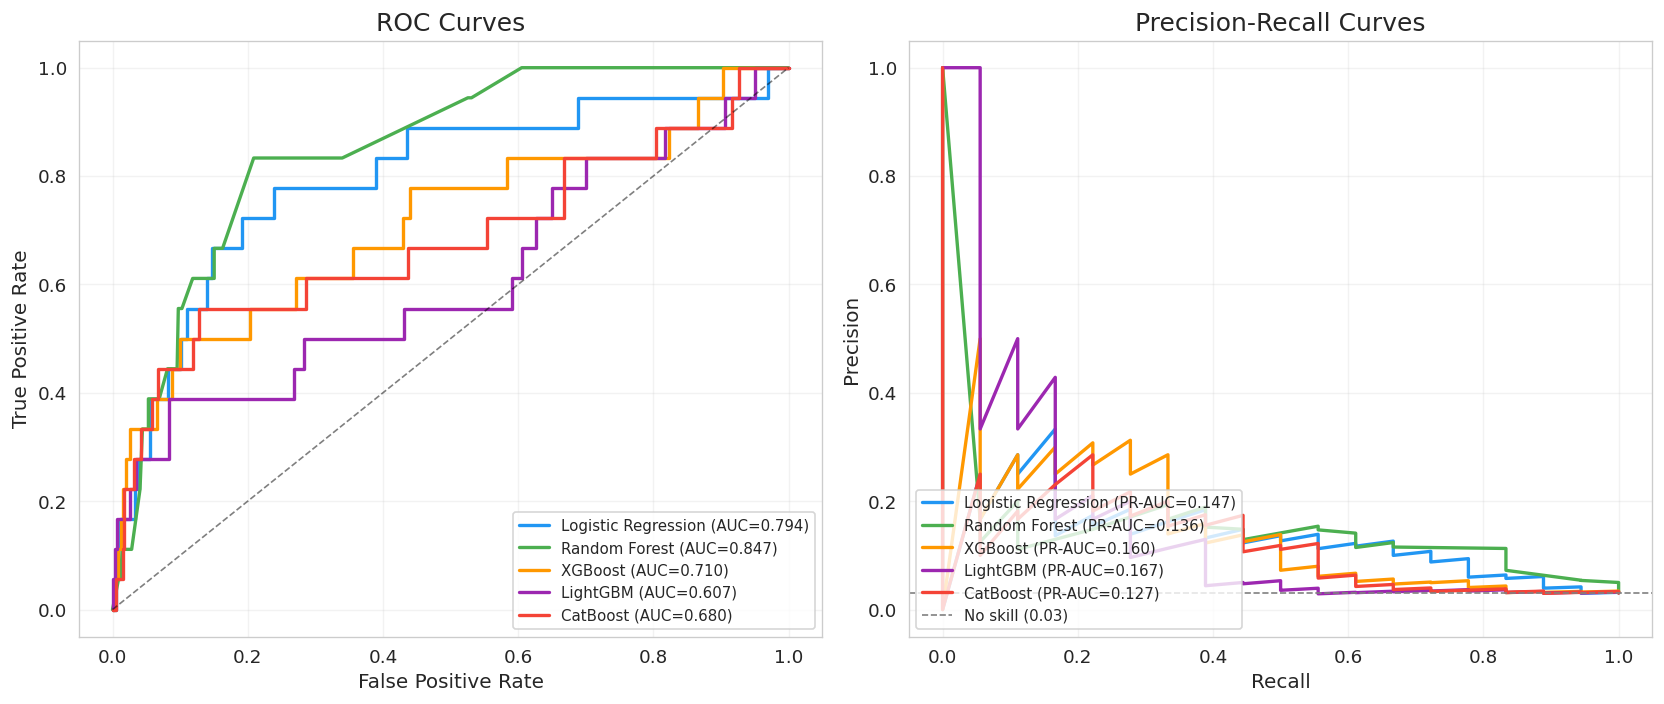

In [83]:
models_data = [
    (lr_proba, "Logistic Regression", "#2196F3"),
    (rf_proba, "Random Forest", "#4CAF50"),
    (xgb_proba, "XGBoost", "#FF9800"),
    (lgb_proba, "LightGBM", "#9C27B0"),
    (cbt_proba, "CatBoost", "#F44336"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC-кривые ---
ax = axes[0]
for proba, label, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{label} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves", fontsize=15)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.25)

# --- PR-кривые ---
ax = axes[1]
for proba, label, color in models_data:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax.plot(recall, precision, color=color, linewidth=2, label=f"{label} (PR-AUC={pr_auc:.3f})")
no_skill = y_test.mean()
ax.axhline(y=no_skill, color="gray", linestyle="--", linewidth=1, label=f"No skill ({no_skill:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves", fontsize=15)
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

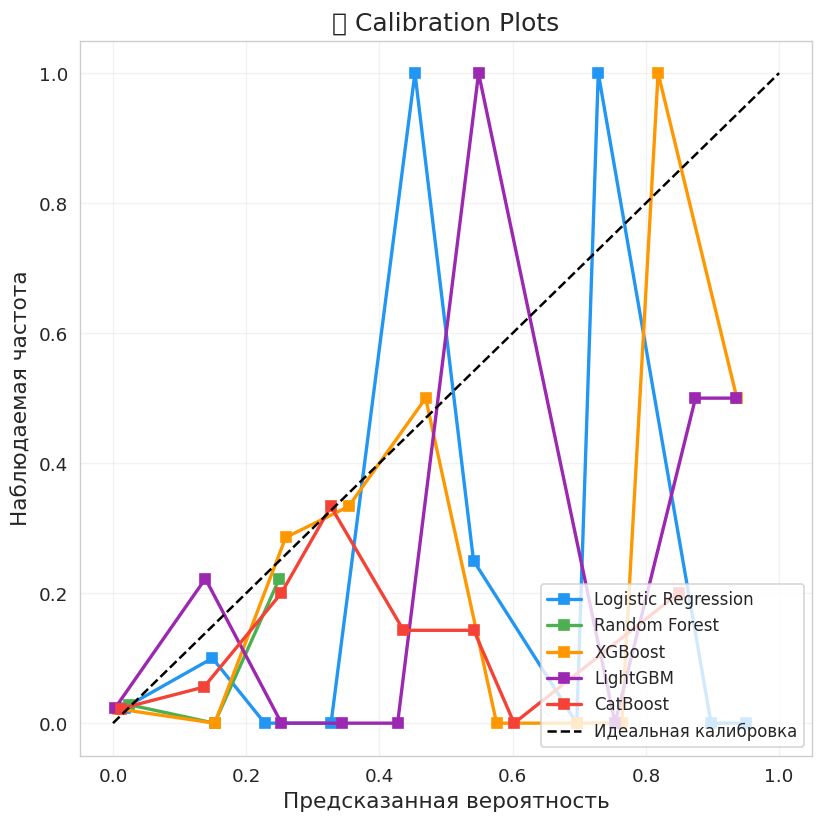

In [70]:
plot_calibration_curve(
    y_test,
    [lr_proba, rf_proba, xgb_proba, lgb_proba, cbt_proba],
    ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"],
    n_bins=10,
)